In [9]:
import os

os.listdir("/content/sample_data")

['README.md',
 'anscombe.json',
 'clusters.csv',
 'markers.csv',
 'expr_matrix.csv',
 'mnist_train_small.csv',
 'california_housing_train.csv',
 'mnist_test.csv',
 'california_housing_test.csv']

In [10]:
import pandas as pd

expr = pd.read_csv("/content/sample_data/expr_matrix.csv", index_col=0)
clusters = pd.read_csv("/content/sample_data/clusters.csv", index_col=0)

print(expr.shape)
print(clusters.shape)

(1895, 2000)
(1895, 1)


In [11]:
import numpy as np
from sklearn.preprocessing import StandardScaler

X = expr.values

# REMOVE NaNs / infs
X = np.nan_to_num(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# clip extreme values (prevents NaN loss)
X_scaled = np.clip(X_scaled, -10, 10)

In [14]:
from tensorflow.keras import layers, models
import tensorflow as tf

input_dim = X_scaled.shape[1]

input_layer = layers.Input(shape=(input_dim,))

encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(16, activation='relu')(encoded)

decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(input_dim)(decoded)

autoencoder = models.Model(input_layer, decoded)

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

autoencoder.fit(
    X_scaled, X_scaled,
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.8003
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.7676
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.7522
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.7415
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.7328
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.7265
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.7219
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.7178
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7143
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.7113


In [15]:
encoder = models.Model(input_layer, encoded)
latent = encoder.predict(X_scaled)

print("Latent shape:", latent.shape)

y = clusters.iloc[:,0].values

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(latent, y)

importance = rf.feature_importances_
top_features = np.argsort(importance)[-20:][::-1]

print("Top DL features:", top_features)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Latent shape: (1895, 16)
Top DL features: [ 4  6  7  5  8 12 15  2 14  0 13  3  1 10  9 11]


In [16]:
# Get decoder weights (last layer)
decoder_weights = autoencoder.layers[-1].get_weights()[0]

# shape: (latent_dim, genes)
print(decoder_weights.shape)

(64, 2000)


In [17]:
gene_names = expr.columns

# importance across all latent neurons
gene_importance = np.sum(np.abs(decoder_weights), axis=0)

top_gene_idx = np.argsort(gene_importance)[-50:][::-1]

top_genes = gene_names[top_gene_idx]

print("Top DL-derived genes:")
print(top_genes[:20])

Top DL-derived genes:
Index(['CKB', 'FABP1', 'DMBT1', 'ADGRG2', 'FABP4', 'IGHG4', 'IGKC', 'ADH1B',
       'MMP1', 'COL1A2', 'FXYD3', 'CEACAM6', 'IGLC2', 'PLIN1', 'TFF3',
       'PMEPA1', 'ID1', 'COL1A1', 'MALAT1', 'LDHA'],
      dtype='object')


In [18]:
y = clusters.iloc[:,0].values

tumor_cluster = np.bincount(y).argmax()  # largest cluster

tumor_cells = X[y == tumor_cluster]
other_cells = X[y != tumor_cluster]

diff = tumor_cells.mean(axis=0) - other_cells.mean(axis=0)

tumor_gene_idx = np.argsort(diff)[-50:][::-1]
tumor_genes = gene_names[tumor_gene_idx]

print("Tumor genes:")
print(tumor_genes[:20])

Tumor genes:
Index(['CEACAM6', 'CCDC88B', 'PMEPA1', 'TSPAN8', 'TFF3', 'KRT8', 'KRT19',
       'PERP', 'LGR5', 'OLFM4', 'VAV3', 'RGMB', 'KRT18', 'S100A4', 'PRAP1',
       'ATP1B1', 'MUC13', 'EFNA1', 'LEFTY1', 'ULBP1'],
      dtype='object')


In [19]:
final_biomarkers = set(top_genes).intersection(set(tumor_genes))

print("Final biomarkers:")
print(final_biomarkers)

Final biomarkers:
{'KRT18', 'CEACAM6', 'TFF3', 'KRT8', 'PMEPA1', 'DEFA6', 'RGMB', 'KRT19', 'OLFM4'}


In [23]:
!pip install gseapy

RF Accuracy: 0.8021108179419525
LR Accuracy: 0.8284960422163589


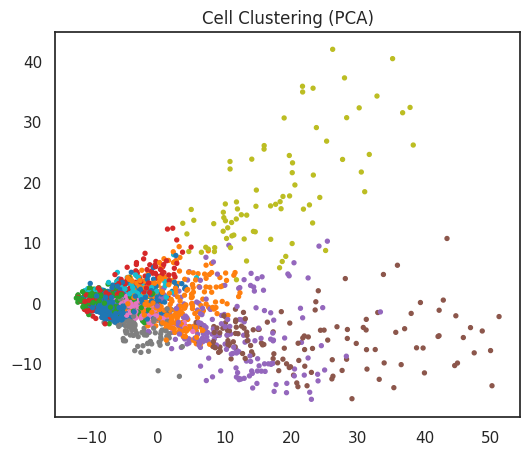

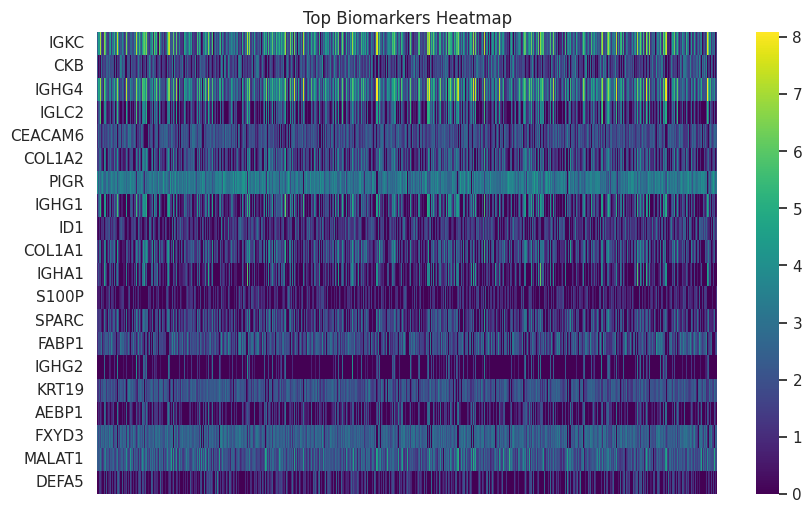

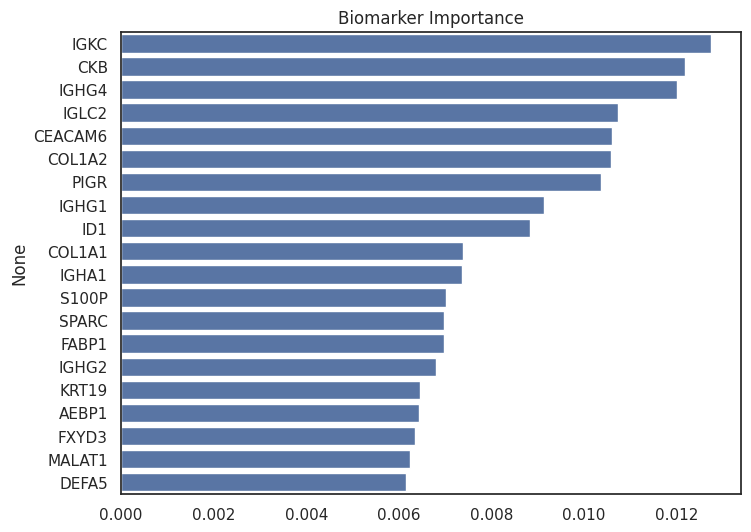

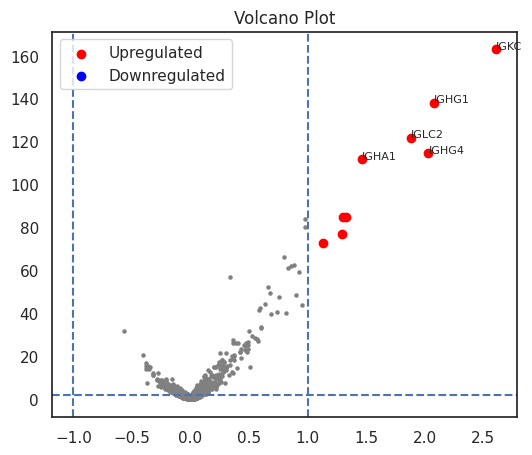

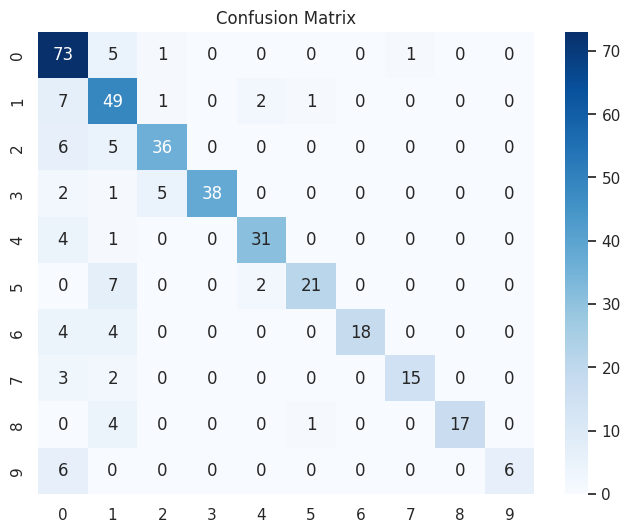

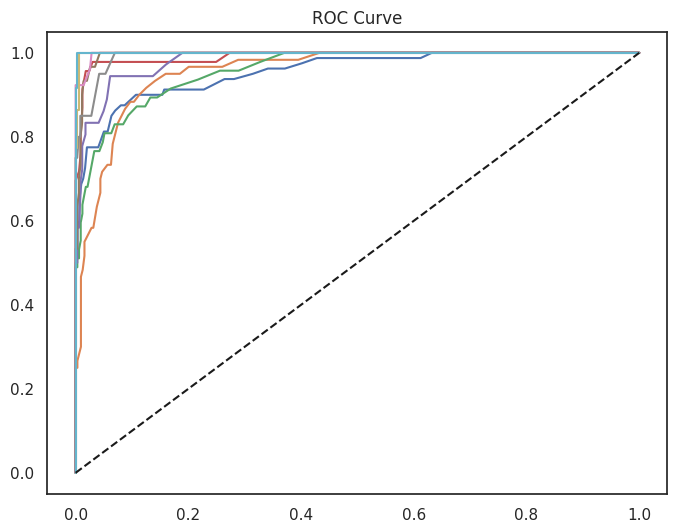

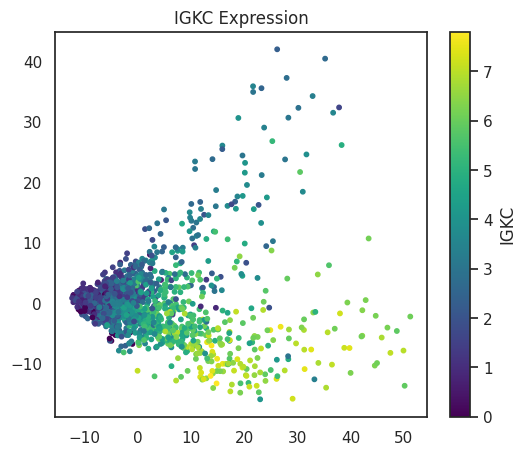

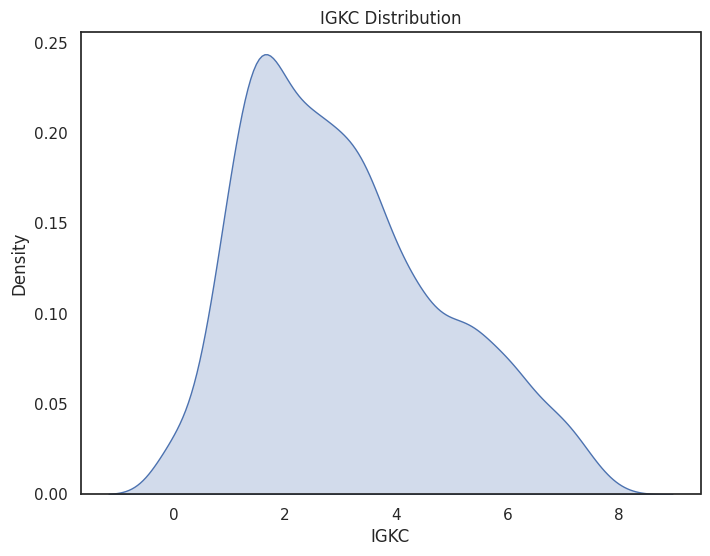

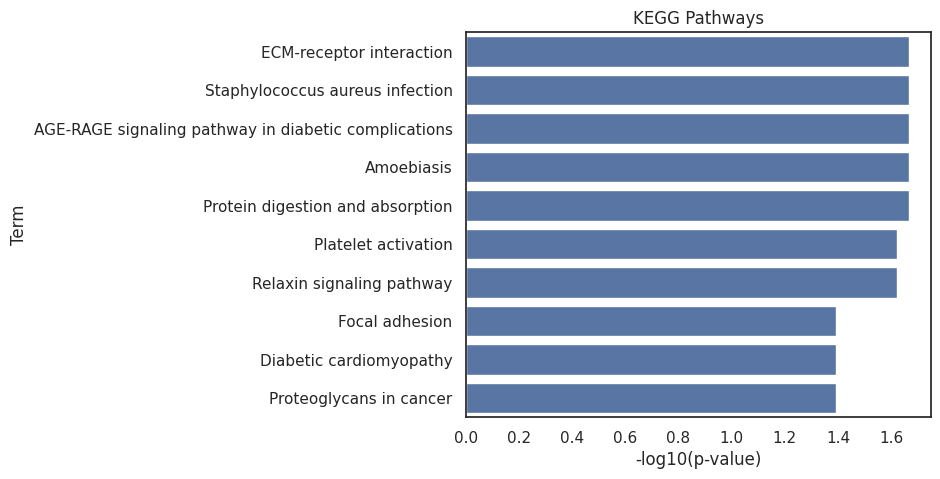

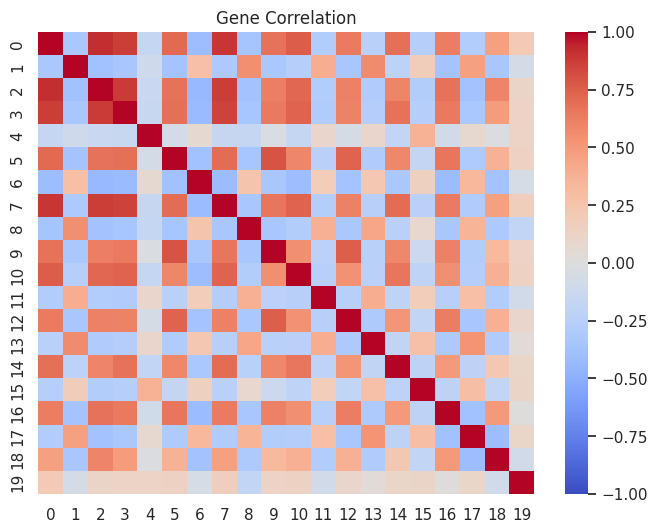

FINAL CLEAN PIPELINE COMPLETE


In [42]:
############################################################
# STEP 1 — IMPORTS
############################################################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve
from sklearn.preprocessing import label_binarize

from scipy.stats import ttest_ind
import gseapy as gp

sns.set(style="white")

############################################################
# STEP 2 — LOAD DATA
############################################################

expr = pd.read_csv("/content/sample_data/expr_matrix.csv", index_col=0)
clusters = pd.read_csv("/content/sample_data/clusters.csv", index_col=0)

y = clusters.iloc[:,0].values
X = expr.values
gene_names = expr.columns

############################################################
# STEP 3 — NORMALIZE
############################################################

X = np.nan_to_num(X)
X_scaled = StandardScaler().fit_transform(X)

############################################################
# STEP 4 — PCA
############################################################

coords = PCA(n_components=2).fit_transform(X_scaled)

############################################################
# STEP 5 — TRAIN TEST SPLIT
############################################################

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

############################################################
# STEP 6 — MODELS
############################################################

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print("RF Accuracy:", rf_acc)
print("LR Accuracy:", lr_acc)

############################################################
# STEP 7 — FEATURE IMPORTANCE
############################################################

importance = rf.feature_importances_
top_idx = np.argsort(importance)[-20:][::-1]
top_genes = gene_names[top_idx]

############################################################
# STEP 8 — PCA CLUSTER
############################################################

plt.figure(figsize=(6,5))
plt.scatter(coords[:,0], coords[:,1], c=y, cmap="tab10", s=8)
plt.title("Cell Clustering (PCA)")
plt.show()

############################################################
# STEP 9 — HEATMAP
############################################################

plt.figure(figsize=(10,6))
sns.heatmap(expr[top_genes].T, cmap="viridis", xticklabels=False)
plt.title("Top Biomarkers Heatmap")
plt.show()

############################################################
# STEP 10 — BIOMARKER IMPORTANCE
############################################################

plt.figure(figsize=(8,6))
sns.barplot(x=importance[top_idx], y=top_genes)
plt.title("Biomarker Importance")
plt.show()

############################################################
# STEP 11 — VOLCANO (FIXED)
############################################################

cluster0 = X[y == np.unique(y)[0]]
cluster1 = X[y == np.unique(y)[1]]

t_stat, p_val = ttest_ind(cluster0, cluster1, axis=0)

# FIXED direction
logFC = np.mean(cluster1, axis=0) - np.mean(cluster0, axis=0)

p_val = np.clip(p_val, 1e-300, 1)
neg_log_p = -np.log10(p_val)

up = (logFC > 1) & (p_val < 0.01)
down = (logFC < -1) & (p_val < 0.01)

plt.figure(figsize=(6,5))

plt.scatter(logFC[~(up|down)], neg_log_p[~(up|down)],
            color='grey', s=5)

plt.scatter(logFC[up], neg_log_p[up],
            color='red', label='Upregulated')

plt.scatter(logFC[down], neg_log_p[down],
            color='blue', label='Downregulated')

plt.axhline(-np.log10(0.01), linestyle='--')
plt.axvline(1, linestyle='--')
plt.axvline(-1, linestyle='--')

# Label top genes
top_idx = np.argsort(p_val)[:5]
for i in top_idx:
    plt.text(logFC[i], neg_log_p[i], gene_names[i], fontsize=8)

plt.legend()
plt.title("Volcano Plot")
plt.show()

############################################################
# STEP 12 — CONFUSION MATRIX
############################################################

cm = confusion_matrix(y_test, rf_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

############################################################
# STEP 13 — ROC CURVE
############################################################

y_bin = label_binarize(y_test, classes=np.unique(y))
rf_probs = rf.predict_proba(X_test)

plt.figure()

for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], rf_probs[:, i])
    plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.show()

############################################################
# STEP 14 — GENE OVERLAY
############################################################

gene = top_genes[0]

plt.figure(figsize=(6,5))
plt.scatter(coords[:,0], coords[:,1], c=expr[gene], cmap="viridis", s=10)
plt.colorbar(label=gene)
plt.title(f"{gene} Expression")
plt.show()

############################################################
# STEP 15 — DISTRIBUTION
############################################################

plt.figure()
sns.kdeplot(expr[gene], fill=True)
plt.title(f"{gene} Distribution")
plt.show()

############################################################
# STEP 16 — KEGG (FIXED)
############################################################

enr = gp.enrichr(
    gene_list=list(top_genes),
    gene_sets="KEGG_2021_Human",
    organism="h. sapiens"
)

res = enr.res2d.head(10)

plt.figure(figsize=(6,5))
sns.barplot(
    x=-np.log10(res["Adjusted P-value"]),
    y=res["Term"]
)
plt.xlabel("-log10(p-value)")
plt.title("KEGG Pathways")
plt.show()

############################################################
# STEP 17 — CORRELATION (IMPROVED)
############################################################

corr = np.corrcoef(expr[top_genes].T)

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Gene Correlation")
plt.show()

############################################################
# DONE
############################################################

print("FINAL CLEAN PIPELINE COMPLETE")